# EDA

In [1]:
# Import libraries
import os
import zipfile
from kaggle.api.kaggle_api_extended import KaggleApi
from pathlib import Path
import shutil
import random

from PIL import Image

import matplotlib.pyplot as plt

import matplotlib.image as mpimg
import seaborn as sns
import pandas as pd
import numpy as np

import hashlib

In [2]:
# --- SETTINGS ---
PROJECT_ROOT = Path("/workspace")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw_temp"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2

SEED = 42 # For reproducibility

os.environ['KAGGLE_CONFIG_DIR'] = str(PROJECT_ROOT)

## 1. - Donwload files

In [3]:
def empty_folder_wo_dsstore(path: Path) -> bool:
    """
    Returns True if the folder is empty or only contains .DS_Store (mac users).
    """
    try:
        visible_elements = [
            item for item in path.iterdir()
            if item.name != ".DS_Store"
        ]
        return len(visible_elements) == 0
    except FileNotFoundError:
        print(f"The folder {path} does not exist.")
        return True
    except PermissionError:
        print(f"You do not have permission to access {path}.")
        return True



In [4]:
def download_dataset():
    if RAW_DATA_DIR.exists():
        print("The temporary download folder already exists. Skipping download..")
        return

    print("Downloading dataset from Kaggle...")
    api = KaggleApi()
    api.authenticate()
    
    # Descargar y descomprimir en carpeta temporal
    api.dataset_download_files("anujms/car-damage-detection", path=RAW_DATA_DIR, unzip=True)
    
    # Borrar el zip residual
    for zip_file in RAW_DATA_DIR.glob("*.zip"):
        zip_file.unlink()
        
    print(f"Download completed in: {RAW_DATA_DIR}")

download_dataset()

Dataset URL: https://www.kaggle.com/datasets/anujms/car-damage-detection
Download completed in: /workspace/data/raw_temp


## 2. - Clean Data

### 2.1 - Clean wrong formats
The format is checked and the images are verified to ensure they are not corrupted.


In [5]:
def clean_images(folder_path):
    print(f"\n Starting cleaning in: {folder_path}")
    valid_exts = {".jpg", ".jpeg", ".png", ".bmp"}
    deleted_count = 0
    checked_count = 0
    
    for filepath in folder_path.rglob("*"):
        if filepath.is_file() and filepath.suffix.lower() in valid_exts:
            checked_count += 1
            try:
                with Image.open(filepath) as img:
                    img.verify() 
            except (IOError, SyntaxError, Image.DecompressionBombError) as e:
                print(f"Corrupted image removed: {filepath.name}")
                filepath.unlink() # Borrar archivo
                deleted_count += 1
                
    print(f"✨ Cleaning finished. Checked: {checked_count}. Deleted: {deleted_count}.")


In [6]:
clean_images(RAW_DATA_DIR)


 Starting cleaning in: /workspace/data/raw_temp
✨ Cleaning finished. Checked: 2300. Deleted: 0.


### 2.2 - Duplicate Detection (Data Leakage)
We do not know the quality of the dataset, and it could contain duplicates. If the image coche_rojo_01.jpg is repeated three times, and unfortunately two appear in Train and one in Test, the model will cheat (it will memorise the photo). Exact duplicates must be removed.

In [7]:
def find_duplicates(folder_path):
    hashes = {}
    duplicates = []
    
    for filepath in folder_path.rglob("*"):
        if filepath.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            with open(filepath, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()
                
            if file_hash in hashes:
                duplicates.append((filepath, hashes[file_hash]))
            else:
                hashes[file_hash] = filepath
                
    return duplicates

In [8]:
dupes = find_duplicates(RAW_DATA_DIR)

print(f"{len(dupes)} exact duplicate images were found.")
if len(dupes) > 0:
    print("Example:", dupes[0])

13 exact duplicate images were found.
Example: (PosixPath('/workspace/data/raw_temp/data1a/training/00-damage/0012.JPEG'), PosixPath('/workspace/data/raw_temp/data1a/training/00-damage/0700.jpeg'))


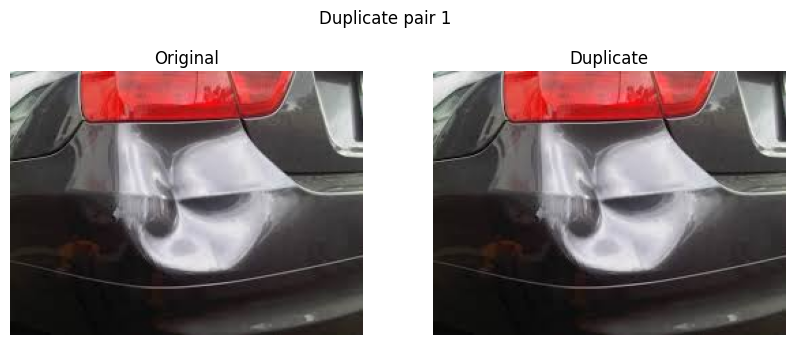

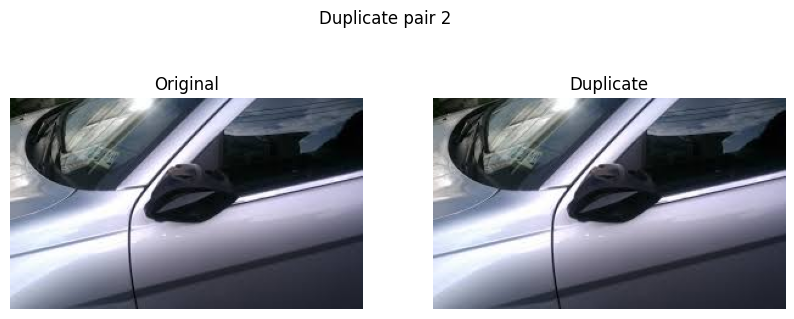

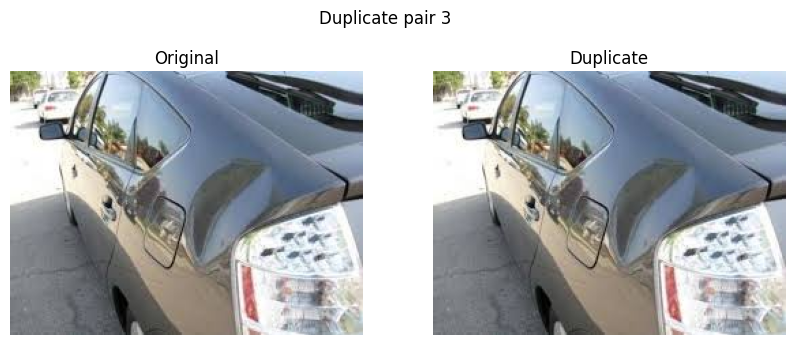

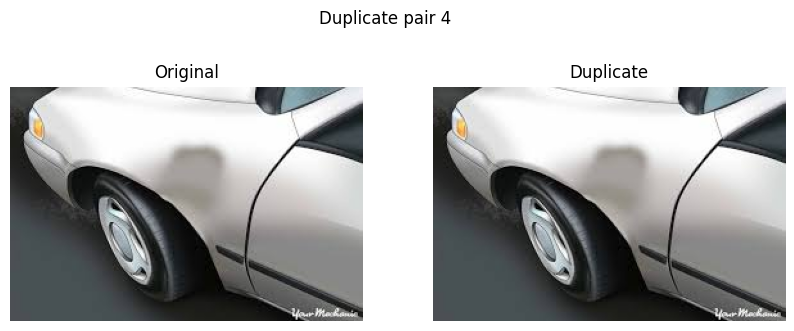

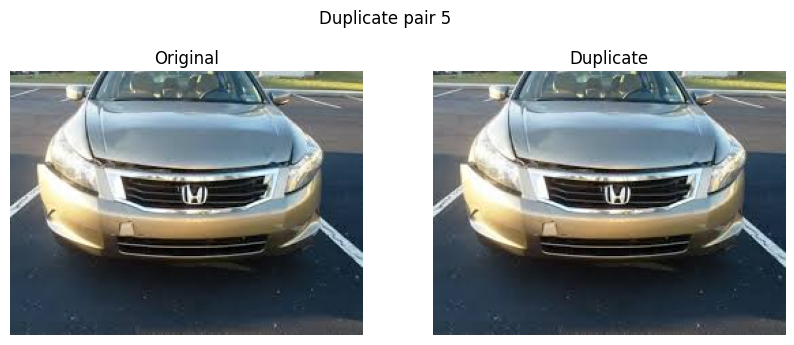

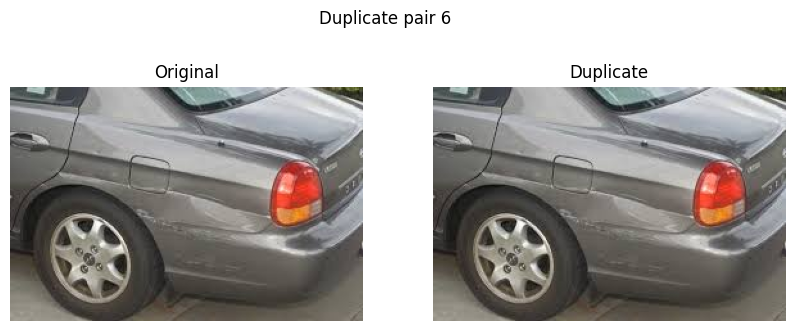

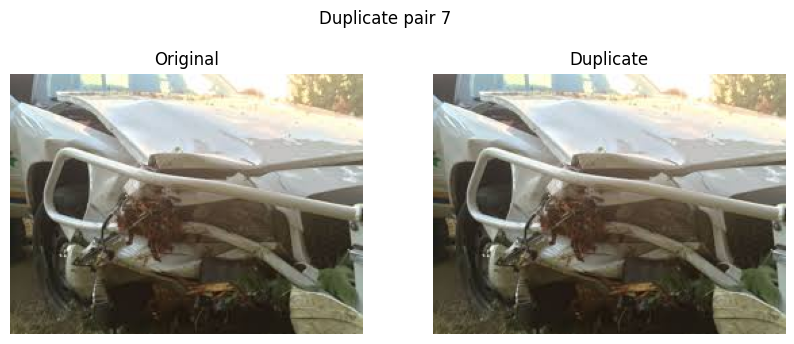

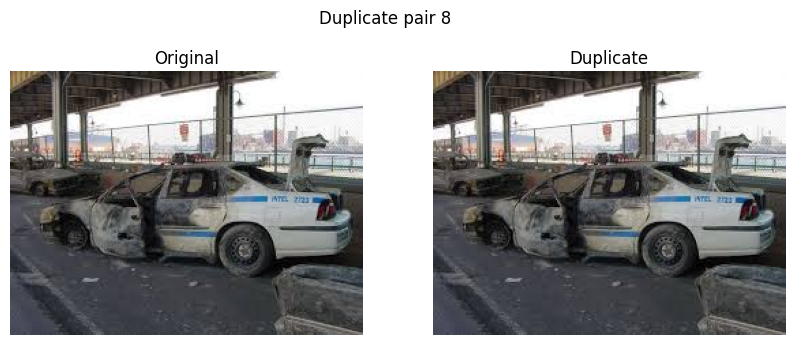

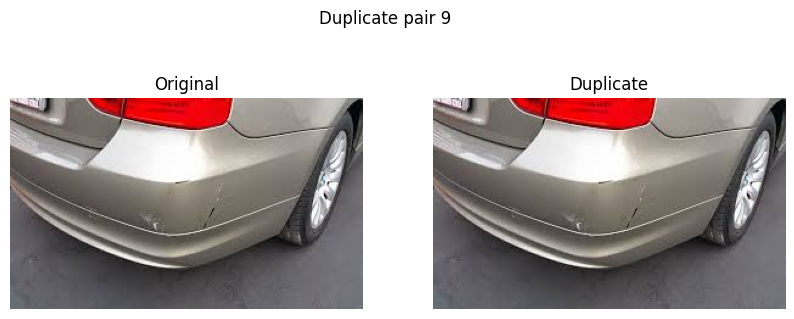

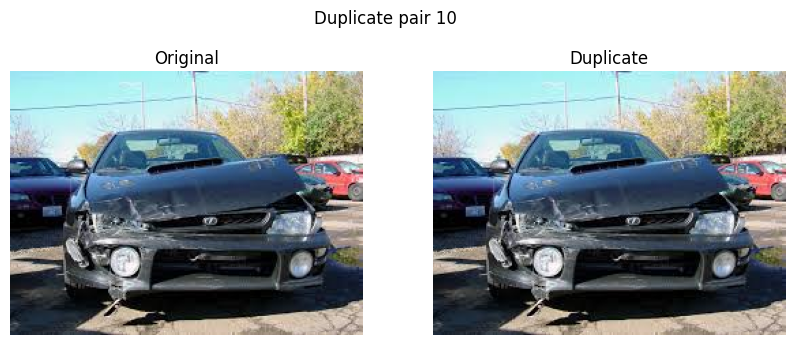

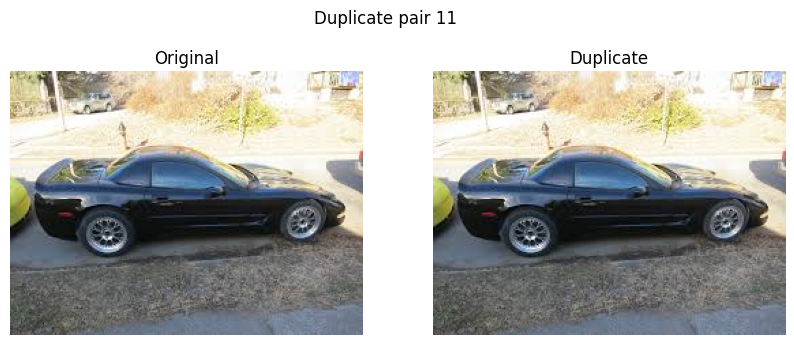

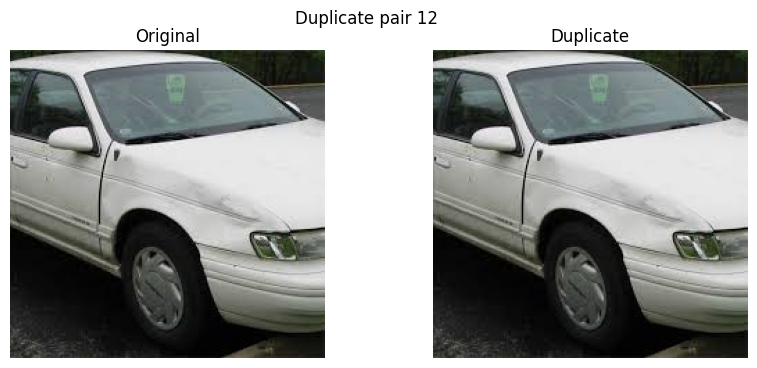

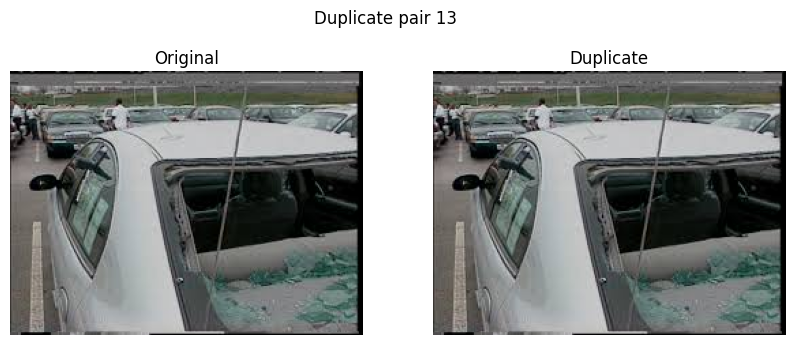

In [9]:
if len(dupes) == 0:
    print("No duplicates found.")
else:
    from matplotlib import pyplot as plt
    for idx, (dup, original) in enumerate(dupes):
        try:
            plt.figure(figsize=(10, 4))
            plt.suptitle(f"Duplicate pair {idx+1}")
            plt.subplot(1, 2, 1)
            plt.imshow(mpimg.imread(str(original)))
            plt.title("Original")
            plt.axis('off')
            plt.subplot(1, 2, 2)
            plt.imshow(mpimg.imread(str(dup)))
            plt.title("Duplicate")
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Error showing pair {idx+1}: {e}")

In [10]:
# Delete duplicates
for dup in dupes:
    os.remove(dup[0])

### 3 - Split (60/20/20 Reorganisation)
The Kaggle dataset can come with an arbitrary split, and often the original validation data is wasted or not well balanced. By mixing everything together and doing our own 60/20/20 split, we ensure that the model is trained, fitted, and evaluated rigorously and honestly.
It searches for all the damaged photos (wherever they are in the original) and all the undamaged ones, mixes them together and distributes them in your new structure.

In [11]:
def create_splits():
    random.seed(SEED)
    
    if PROCESSED_DATA_DIR.exists():
        shutil.rmtree(PROCESSED_DATA_DIR)
    
    splits = ['train', 'val', 'test']
    labels = ['damage', 'whole']
    
    for split in splits:
        for label in labels:
            (PROCESSED_DATA_DIR / split / label).mkdir(parents=True, exist_ok=True)

    def get_files_by_label(keyword):
        files = []
        for filepath in RAW_DATA_DIR.rglob("*"):
            if filepath.is_file() and filepath.suffix.lower() in {'.jpg', '.jpeg', '.png'}:
                if keyword in filepath.parent.name.lower():
                    files.append(filepath)
        return files

    for label in labels:
        all_files = get_files_by_label(label)
        
        random.shuffle(all_files)
        
        total = len(all_files)
        if total == 0:
            print(f"Warning: No images found for the tag '{label}'")
            continue
            
        train_end = int(total * TRAIN_RATIO)
        val_end = train_end + int(total * VAL_RATIO)
        
        split_files = {
            'train': all_files[:train_end],
            'val':   all_files[train_end:val_end],
            'test':  all_files[val_end:]
        }
        
        print(f"Processing class '{label}': Total {total}")
        print(f"   ↳ Train: {len(split_files['train'])} | Val: {len(split_files['val'])} | Test: {len(split_files['test'])}")
        
        for split, files in split_files.items():
            for f in files:
                shutil.copy2(f, PROCESSED_DATA_DIR / split / label / f.name)

    print(f"\nDataset successfully prepared in: {PROCESSED_DATA_DIR}")



In [12]:
create_splits()

Processing class 'damage': Total 1138
   ↳ Train: 682 | Val: 227 | Test: 229
Processing class 'whole': Total 1149
   ↳ Train: 689 | Val: 229 | Test: 231

Dataset successfully prepared in: /workspace/data/processed


In [13]:
for split in ['train', 'val', 'test']:
    for label in ['damage', 'whole']:
        path = PROCESSED_DATA_DIR / split / label
        count = len(list(path.glob('*')))
        print(f"{split}/{label}: {count} imágenes")

train/damage: 604 imágenes
train/whole: 616 imágenes
val/damage: 220 imágenes
val/whole: 227 imágenes
test/damage: 223 imágenes
test/whole: 229 imágenes


## 3. - EDA: Exploratory Data Analysis
Deep Exploratory Data Analysis (distribution of aspect ratios, pixel intensity analysis) will be performed exclusively on the Training set after the train/val/test split. This ensures that the model architecture and preprocessing decisions are not biased by the test data, providing a realistic evaluation of the model's generalization capabilities.

In [14]:
def show_samples(folder, title):
    plt.figure(figsize=(12, 4))
    images = list(folder.glob("*"))[:5]
    for i, img_path in enumerate(images):
        plt.subplot(1, 5, i+1)
        img = mpimg.imread(str(img_path))
        plt.imshow(img)
        plt.axis('off')
        plt.title(title)
    plt.show()

Damaged Route: /workspace/data/processed/train/damage
Intactos Route: /workspace/data/processed/train/whole
Images for EDA (Train): 604 damages vs 616 whole


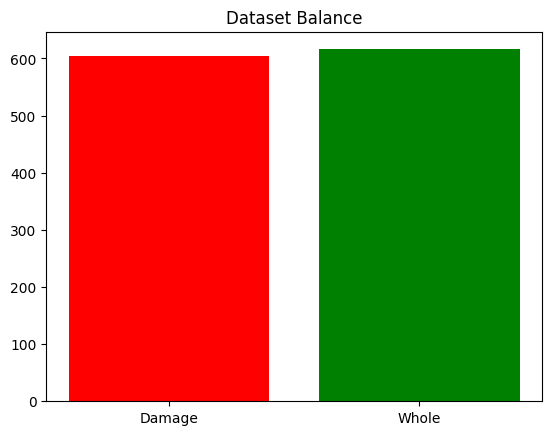

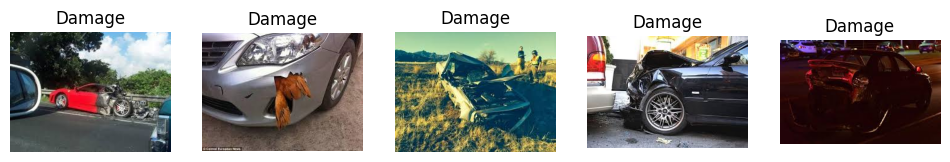

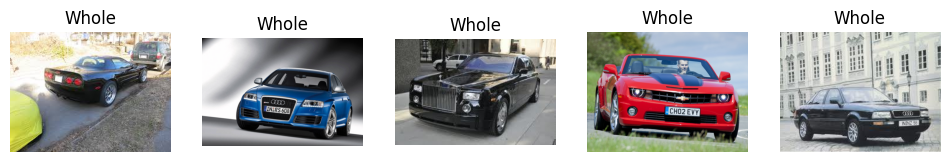

In [15]:
TRAIN_PROCESSED_DATA_DIR = PROCESSED_DATA_DIR / "train"

damage_dir = TRAIN_PROCESSED_DATA_DIR / "damage"
whole_dir = TRAIN_PROCESSED_DATA_DIR / "whole"

if not damage_dir.exists():
    print(f"Error: I cannot find the folder in {damage_dir}")
    print(f"Current content of train: {[x.name for x in TRAIN_PROCESSED_DATA_DIR.iterdir()]}")
else:
    print(f"Damaged Route: {damage_dir}")
    print(f"Intactos Route: {whole_dir}")
    
    n_damage = len(list(damage_dir.glob("*")))
    n_whole = len(list(whole_dir.glob("*")))
    print(f"Images for EDA (Train): {n_damage} damages vs {n_whole} whole")


plt.bar(['Damage', 'Whole'], [n_damage, n_whole], color=['red', 'green'])
plt.title("Dataset Balance")
plt.show()

show_samples(damage_dir, "Damage")
show_samples(whole_dir, "Whole")

### 3.1 - Analysis of Dimensions and Aspect Ratio
CNNs require a fixed input (e.g. 224x224 pixels). If the original images are very elongated (panoramic) or very small (icons), resizing them will distort or pixelate them, causing key damage information to be lost.

In [16]:
def get_image_metadata(folder_path, label):
    data = []
    for filepath in folder_path.rglob("*"):
        if filepath.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            with Image.open(filepath) as img:
                width, height = img.size
                data.append({
                    "filename": filepath.name,
                    "width": width,
                    "height": height,
                    "aspect_ratio": width / height,
                    "label": label
                })
    return data

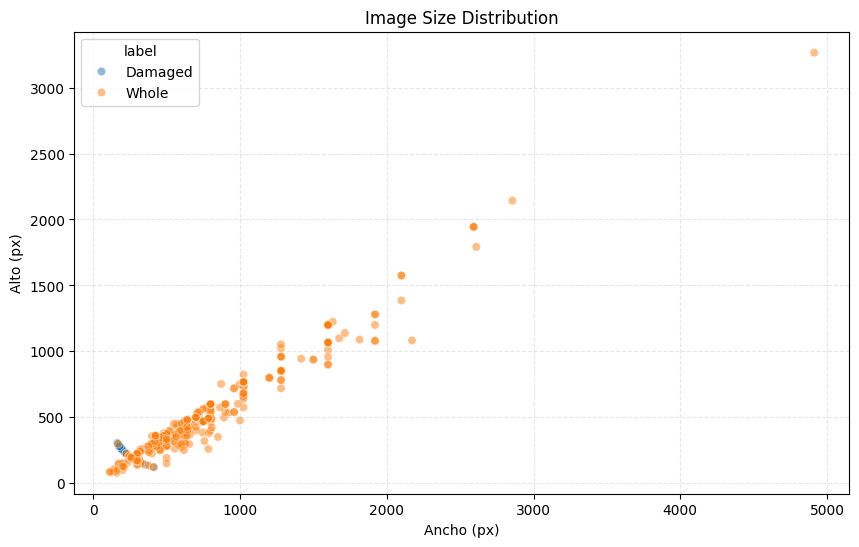

         width                                                              \
         count        mean         std    min    25%    50%    75%     max   
label                                                                        
Damaged  604.0  266.880795   26.355568  165.0  259.0  261.0  276.0   414.0   
Whole    616.0  648.376623  465.043942  112.0  300.0  580.0  800.0  4912.0   

        height              ...                aspect_ratio           \
         count        mean  ...    75%     max        count     mean   
label                       ...                                        
Damaged  604.0  190.725166  ...  194.0   306.0        604.0  1.42867   
Whole    616.0  447.521104  ...  533.5  3264.0        616.0  1.47082   

                                                                     
              std       min       25%       50%       75%       max  
label                                                                
Damaged  0.272068  0.539216  1.335052 

In [17]:
meta_damage = get_image_metadata(damage_dir, "Damaged")
meta_whole = get_image_metadata(whole_dir, "Whole")

df = pd.DataFrame(meta_damage + meta_whole)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="width", y="height", hue="label", alpha=0.5)
plt.title("Image Size Distribution")
plt.xlabel("Ancho (px)")
plt.ylabel("Alto (px)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print(df.groupby('label')[['width', 'height', 'aspect_ratio']].describe())

As we can see in the distribution, most images have the same form factor (linear distribution) but come in many sizes (they are scattered), so we have to be careful when choosing the training size, because the smallest ones will become pixelated when resized (they are quite close to 0.0).

### 3.2 - Brightness and Intensity Analysis (Bias Detection)
We want to avoid bias in the brightness of the images, which would make the model unreliable. Imagine that all the photos of "Damaged Cars" were taken by experts on cloudy days or in dark garages, and those of "Undamaged Cars" are bright marketing photos. The model could learn that "Dark = Damaged".

In [18]:
def get_brightness(folder_path):
    brightness_vals = []
    for filepath in folder_path.rglob("*"):
        if filepath.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            with Image.open(filepath) as img:
                img_gray = img.convert('L')
                stat = np.array(img_gray).mean()
                brightness_vals.append(stat)
    return brightness_vals

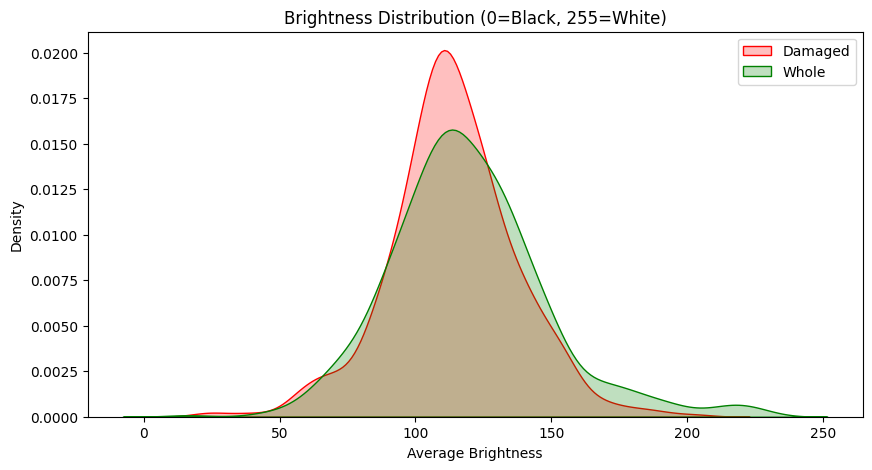

In [19]:
bright_damage = get_brightness(damage_dir)
bright_whole = get_brightness(whole_dir)

plt.figure(figsize=(10, 5))
sns.kdeplot(bright_damage, label='Damaged', fill=True, color='red')
sns.kdeplot(bright_whole, label='Whole', fill=True, color='green')
plt.title("Brightness Distribution (0=Black, 255=White)")
plt.xlabel("Average Brightness")
plt.legend()
plt.show()

Given that the two curves overlap, there is no bias.

Summary of the EDA:

* Geometric Consistency: It is decided that the resize size will be: (Resize vs Padding).
* Bias Analysis (Brightness): A biased model is avoided.